# LLM Attention Matrislerinden Subject/Object Tespiti

## 1. Setup

In [ ]:
#!pip install transformers
#!pip install torch
#!pip install openpyxl


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 42.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 25.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 30.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 734.9 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 67.2 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitli

In [ ]:
from huggingface_hub import login
login()


In [ ]:
import pandas as pd

from google.colab import files
uploaded = files.upload()  # dataset.xlsx

df = pd.read_excel(list(uploaded.keys())[0])

df['tokens'] = df['tokens'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)
df['labels'] = df['labels'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

df.head()


Saving dataset.xlsx to dataset (4).xlsx


,sentence,tokens,labels
0,Ali defteri aldı.,"[Ali, defteri, aldı, .]","[subject, object, other, other]"
1,Ayşe elmayı yedi.,"[Ayşe, elmayı, yedi, .]","[subject, object, other, other]"
2,Mehmet elmayı gördü.,"[Mehmet, elmayı, gördü, .]","[subject, object, other, other]"
3,Çocuk deftere yazdı.,"[Çocuk, deftere, yazdı, .]","[subject, object, other, other]"
4,Kedi sandalyeye oturdu.,"[Kedi, sandalyeye, oturdu, .]","[subject, object, other, other]"


In [15]:
from transformers import AutoTokenizer, AutoModel
import torch

model_name = "ytu-ce-cosmos/turkish-base-bert-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name, output_attentions=True)

model.eval()
print("✔️ Model ve tokenizer başarıyla yüklendi!")





tokenizer_config.json:   0%|          | 0.00/402 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/263k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/445M [00:00<?, ?B/s]

✔️ Model ve tokenizer başarıyla yüklendi!


In [19]:
def get_attention_for_sentence(sentence):
    if not isinstance(sentence, str):
        return None, None
    inputs = tokenizer(sentence, return_tensors="pt", truncation=True)
    with torch.no_grad():
        outputs = model(**inputs)
    return outputs.attentions, inputs['input_ids'][0]



In [20]:
def extract_features(attentions):
    features = []
    for layer in attentions:
        layer_mean = layer[0].mean(dim=0)  # [seq_len, seq_len]
        token_features = [layer_mean[i].tolist() for i in range(layer_mean.shape[0])]
        features.append(token_features)
    return torch.mean(torch.tensor(features), dim=0).tolist()


In [23]:
def extract_token_features(attentions):
    """
    attention tuple'ından [seq_len x num_layers] boyutunda feature çıkarır
    """
    layer_feats = []
    for layer in attentions:
        layer = layer[0]  # [num_heads, seq_len, seq_len]
        avg_head = layer.mean(dim=0)  # [seq_len, seq_len]
        token_feats = avg_head.sum(dim=1)  # [seq_len]
        layer_feats.append(token_feats)
    stacked = torch.stack(layer_feats, dim=1)  # [seq_len, num_layers]
    return stacked.tolist()


In [ ]:
# bozuk satırları filtrele
df = df[df['sentence'].apply(lambda x: isinstance(x, str))]

X, y = [], []
for _, row in df.iterrows():
    sentence = row['sentence']
    labels = row['labels']

    attns, input_ids = get_attention_for_sentence(sentence)
    if attns is None:
        continue

    feats = extract_token_features(attns)
    min_len = min(len(feats), len(labels))
    X.extend(feats[:min_len])
    y.extend(labels[:min_len])



In [25]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y)

clf = RandomForestClassifier()
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

      object       0.27      0.24      0.25        17
       other       0.55      0.69      0.61        35
     subject       0.30      0.18      0.22        17

    accuracy                           0.45        69
   macro avg       0.37      0.37      0.36        69
weighted avg       0.42      0.45      0.42        69



In [26]:
import torch
import seaborn as sns
import matplotlib.pyplot as plt


In [27]:
def plot_attention_heatmap(sentence, layer=-1, head=0):
    inputs = tokenizer(sentence, return_tensors="pt", truncation=True)
    with torch.no_grad():
        outputs = model(**inputs)

    attentions = outputs.attentions  # Tuple: [layers][batch, heads, seq, seq]
    tokens = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])

    attn = attentions[layer][0][head]  # shape: [seq_len, seq_len]

    plt.figure(figsize=(10, 8))
    sns.heatmap(attn, xticklabels=tokens, yticklabels=tokens, cmap="Blues", square=True, cbar=True)
    plt.title(f"Attention Heatmap – Layer {layer}, Head {head}")
    plt.xlabel("Dikkat Verilen Token")
    plt.ylabel("Dikkat Veren Token")
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()


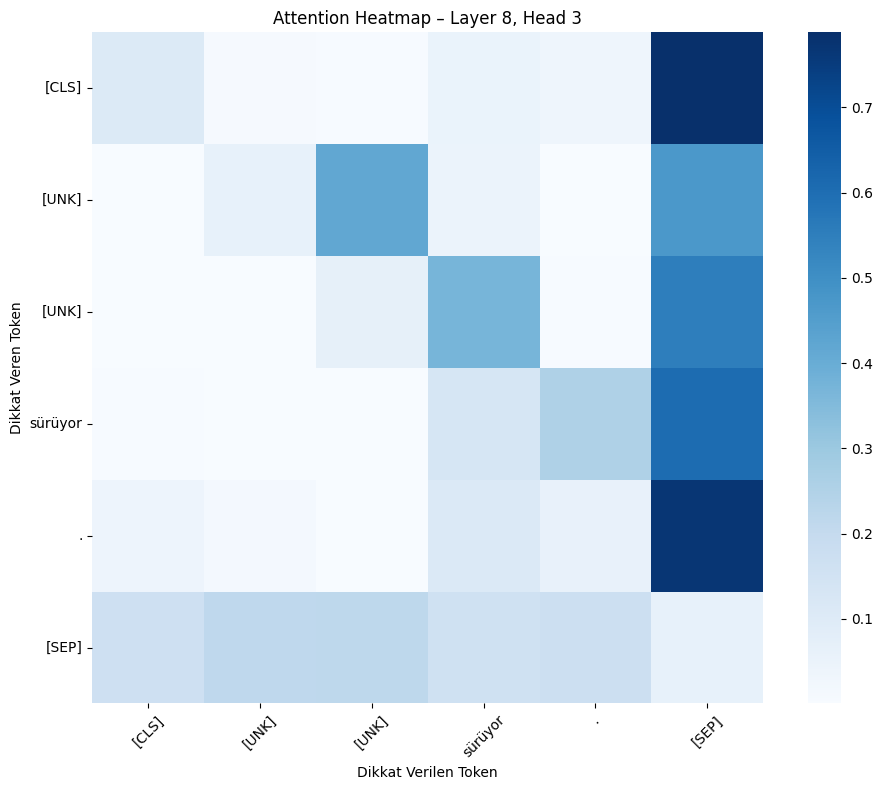

In [39]:
plot_attention_heatmap("Bisikleti Berkay sürüyor.", layer=8, head=3)


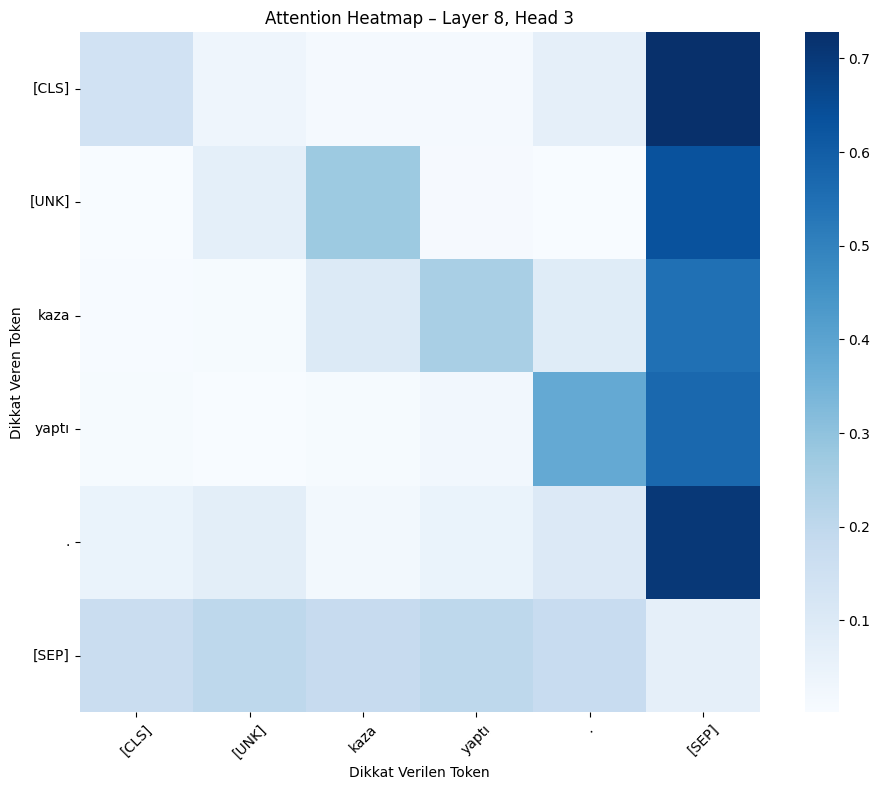

In [41]:
plot_attention_heatmap("Şoför kaza yaptı.", layer=8, head=3)

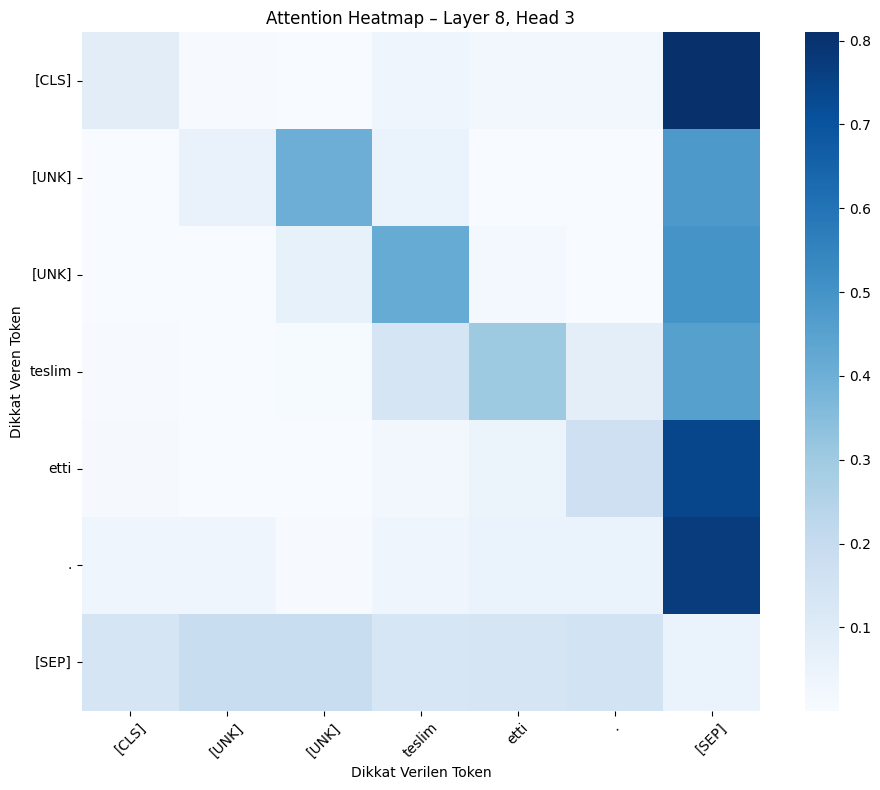

In [40]:
plot_attention_heatmap("Fotoğrafı Merve teslim etti.", layer=8, head=3)

In [31]:
correct_sentences = []
incorrect_sentences = []

for i, row in df.iterrows():
    sentence = row['sentence']
    true_labels = row['labels']

    attns, _ = get_attention_for_sentence(sentence)
    if attns is None:
        continue
    feats = extract_token_features(attns)
    if len(feats) != len(true_labels):
        continue

    preds = clf.predict(feats)

    if list(preds) == true_labels:
        correct_sentences.append((sentence, true_labels, preds))
    else:
        incorrect_sentences.append((sentence, true_labels, preds))


In [ ]:
results = []

for i, row in df.iterrows():
    sentence = row['sentence']
    true_labels = row['labels']

    # label sayısı minimum 3 olmalı ki anlamlı olsun
    if not isinstance(sentence, str) or not isinstance(true_labels, list) or len(true_labels) < 2:
        continue

    attns, input_ids = get_attention_for_sentence(sentence)
    if attns is None:
        continue

    feats = extract_token_features(attns)
    preds = clf.predict(feats)

    min_len = min(len(true_labels), len(preds), len(input_ids))
    tokens = tokenizer.convert_ids_to_tokens(input_ids[:min_len])

    results.append({
        "sentence": sentence,
        "tokens": tokens,
        "true_labels": true_labels[:min_len],
        "predicted_labels": list(preds[:min_len]),
        "correct": true_labels[:min_len] == list(preds[:min_len])
    })


In [37]:
import pandas as pd

df_results = pd.DataFrame(results)
df_results.head()


,sentence,tokens,true_labels,predicted_labels,correct
0,Ali defteri aldı.,"[[CLS], [UNK], defteri, aldı]","[subject, object, other, other]","[subject, object, other, other]",True
1,Ayşe elmayı yedi.,"[[CLS], [UNK], elma, ##yı]","[subject, object, other, other]","[subject, other, other, other]",False
2,Mehmet elmayı gördü.,"[[CLS], [UNK], elma, ##yı]","[subject, object, other, other]","[subject, object, other, other]",True
3,Çocuk deftere yazdı.,"[[CLS], [UNK], defter, ##e]","[subject, object, other, other]","[subject, object, other, other]",True
4,Kedi sandalyeye oturdu.,"[[CLS], [UNK], sandalye, ##ye]","[subject, object, other, other]","[subject, object, other, other]",True


In [38]:
df_results.to_excel("model_subject_object_results.xlsx", index=False)
from google.colab import files
files.download("model_subject_object_results.xlsx")



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>